EDA - Exploratory Data Analysis

1. **Importing necessary libraries and modules**

In [11]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from configurations.config import MOVIES_CSV, RATINGS_CSV, TAGS_CSV
from eda_analysis.eda_functions import check_schema

2. **Initial Overview of Raw Data**

In [12]:
# Load datasets
movies = pl.read_csv(MOVIES_CSV)
ratings = pl.read_csv(RATINGS_CSV)
tags = pl.read_csv(TAGS_CSV)


In [13]:
# Check dataset structure
check_schema(movies, "Movies")
check_schema(ratings, "Ratings")
check_schema(tags, "Tags")


--- Movies ---
Shape: 9742 rows x 3 columns
Schema:
   movieId             Int64
   title               String
   genres              String

--- Ratings ---
Shape: 100836 rows x 4 columns
Schema:
   userId              Int64
   movieId             Int64
   rating              Float64
   timestamp           Int64

--- Tags ---
Shape: 3683 rows x 4 columns
Schema:
   userId              Int64
   movieId             Int64
   tag                 String
   timestamp           Int64



* Through these check schema tables we can see our schema and data types are all good except the timestamp column, so next steps are:
    - We should transform it so it would be easier to plot, filter and group by date
    - Make a transformation step while ingesting data so it's applied consistently to all future data (in our project it should be part of featurization)

In [14]:
# transforming unix timestamps to datetime
ratings = ratings.with_columns(pl.from_epoch("timestamp", time_unit = "s").alias("timestamp"))
tags = tags.with_columns(pl.from_epoch("timestamp", time_unit = "s").alias("timestamp"))

# Verify conversion
print(ratings.head(2))
print(tags.head(2))

shape: (2, 4)
┌────────┬─────────┬────────┬─────────────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp           │
│ ---    ┆ ---     ┆ ---    ┆ ---                 │
│ i64    ┆ i64     ┆ f64    ┆ datetime[μs]        │
╞════════╪═════════╪════════╪═════════════════════╡
│ 1      ┆ 1       ┆ 4.0    ┆ 2000-07-30 18:45:03 │
│ 1      ┆ 3       ┆ 4.0    ┆ 2000-07-30 18:20:47 │
└────────┴─────────┴────────┴─────────────────────┘
shape: (2, 4)
┌────────┬─────────┬─────────────────┬─────────────────────┐
│ userId ┆ movieId ┆ tag             ┆ timestamp           │
│ ---    ┆ ---     ┆ ---             ┆ ---                 │
│ i64    ┆ i64     ┆ str             ┆ datetime[μs]        │
╞════════╪═════════╪═════════════════╪═════════════════════╡
│ 2      ┆ 60756   ┆ funny           ┆ 2015-10-24 19:29:54 │
│ 2      ┆ 60756   ┆ Highly quotable ┆ 2015-10-24 19:29:56 │
└────────┴─────────┴─────────────────┴─────────────────────┘


In [15]:
# Preview first 4 rows
print(movies.head(3))
print(ratings.head(3))
print(tags.head(3))

shape: (3, 3)
┌─────────┬─────────────────────────┬─────────────────────────────────┐
│ movieId ┆ title                   ┆ genres                          │
│ ---     ┆ ---                     ┆ ---                             │
│ i64     ┆ str                     ┆ str                             │
╞═════════╪═════════════════════════╪═════════════════════════════════╡
│ 1       ┆ Toy Story (1995)        ┆ Adventure|Animation|Children|C… │
│ 2       ┆ Jumanji (1995)          ┆ Adventure|Children|Fantasy      │
│ 3       ┆ Grumpier Old Men (1995) ┆ Comedy|Romance                  │
└─────────┴─────────────────────────┴─────────────────────────────────┘
shape: (3, 4)
┌────────┬─────────┬────────┬─────────────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp           │
│ ---    ┆ ---     ┆ ---    ┆ ---                 │
│ i64    ┆ i64     ┆ f64    ┆ datetime[μs]        │
╞════════╪═════════╪════════╪═════════════════════╡
│ 1      ┆ 1       ┆ 4.0    ┆ 2000-07-30 18:45:03 │
│ 1      ┆ 3

In [16]:
# Check missing values
for name, df in [("Movies", movies), ("Ratings", ratings), ("Tags", tags)]:
    print(f"\n{name} missing values:")
    print(df.null_count())


Movies missing values:
shape: (1, 3)
┌─────────┬───────┬────────┐
│ movieId ┆ title ┆ genres │
│ ---     ┆ ---   ┆ ---    │
│ u32     ┆ u32   ┆ u32    │
╞═════════╪═══════╪════════╡
│ 0       ┆ 0     ┆ 0      │
└─────────┴───────┴────────┘

Ratings missing values:
shape: (1, 4)
┌────────┬─────────┬────────┬───────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp │
│ ---    ┆ ---     ┆ ---    ┆ ---       │
│ u32    ┆ u32     ┆ u32    ┆ u32       │
╞════════╪═════════╪════════╪═══════════╡
│ 0      ┆ 0       ┆ 0      ┆ 0         │
└────────┴─────────┴────────┴───────────┘

Tags missing values:
shape: (1, 4)
┌────────┬─────────┬─────┬───────────┐
│ userId ┆ movieId ┆ tag ┆ timestamp │
│ ---    ┆ ---     ┆ --- ┆ ---       │
│ u32    ┆ u32     ┆ u32 ┆ u32       │
╞════════╪═════════╪═════╪═══════════╡
│ 0      ┆ 0       ┆ 0   ┆ 0         │
└────────┴─────────┴─────┴───────────┘


In [17]:
# Count empty strings in genres and tag columns since they are like nulls in a way
empty_tags = tags.filter(pl.col("tag").str.strip_chars() == "").height
empty_genres = movies.filter(pl.col("genres").str.strip_chars() == "").height
empty_title = movies.filter(pl.col("title").str.strip_chars() == "").height

print(f"Empty strings in tags column: {empty_tags}")
print(f"Empty strings in genres column: {empty_genres}")
print(f"Empty strings in title column: {empty_title}")

Empty strings in tags column: 0
Empty strings in genres column: 0
Empty strings in title column: 0


* Since there are no null values and empty strings we are good to go

In [18]:
# Check how many rows in genres have value "(no genres listed)"
no_genres_value_df = movies.filter(pl.col("genres") == "(no genres listed)")
no_tags_value_count = no_genres_value_df.height

print(f"Number of rows with (no genres listed): {no_genres_value_count}")

# Check if these movies have corresponding tags in tags file
tagged_no_genres_movies = no_genres_value_df.join(tags, on="movieId",how="inner")

if tagged_no_genres_movies.is_empty():
    print("No movies with (no genres listed) have corresponding tags")
else:
    # Count the number of unique movies found
    unique_movies_count = tagged_no_genres_movies.select("movieId").unique().shape[0]

    print(f"Yes, {unique_movies_count} movies with 'no genres listed' have tags.")
    print("Here are the first few examples:")
    print(tagged_no_genres_movies.head(5))


NameError: name 'no_genres_value_count' is not defined

3. **Data integrity**

In [111]:
# Check if movieId in movies have duplicates
duplicate_movie_ids = movies.filter(pl.col("movieId").is_duplicated())
print(f"Number of duplicated movieIds: {duplicate_movie_ids.height}")

duplicate_titles = movies.filter(pl.col("title").is_duplicated())
print(f"Number of duplicated titles: {duplicate_titles.height}")

Number of duplicated movieIds: 0
Number of duplicated titles: 10


In [112]:
# Since we have duplicated titles we need to check if that makes sense
duplicated_titles_df = movies.filter(pl.col("title").is_duplicated())

print(duplicated_titles_df)

shape: (10, 3)
┌─────────┬─────────────────────────────────┬─────────────────────────────────┐
│ movieId ┆ title                           ┆ genres                          │
│ ---     ┆ ---                             ┆ ---                             │
│ i64     ┆ str                             ┆ str                             │
╞═════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 838     ┆ Emma (1996)                     ┆ Comedy|Drama|Romance            │
│ 2851    ┆ Saturn 3 (1980)                 ┆ Adventure|Sci-Fi|Thriller       │
│ 6003    ┆ Confessions of a Dangerous Min… ┆ Comedy|Crime|Drama|Thriller     │
│ 26958   ┆ Emma (1996)                     ┆ Romance                         │
│ 32600   ┆ Eros (2004)                     ┆ Drama                           │
│ 34048   ┆ War of the Worlds (2005)        ┆ Action|Adventure|Sci-Fi|Thrill… │
│ 64997   ┆ War of the Worlds (2005)        ┆ Action|Sci-Fi                   │
│ 144606  ┆ Confessions o

* Since there are duplicated values of titles on the different movieId that we will need to handle through featurization

In [131]:
# Check if formatting of genres is consistent
valid_genres_list = [
    "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
    "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western","IMAX"
]
genres_pattern = "|".join(valid_genres_list)
full_pattern_case_insensitive = f"^(?i)(?:\(no genres listed\)|(?:{genres_pattern})(?:\|(?:{genres_pattern}))*)$"

invalid_rows_df = movies.filter(~pl.col("genres").str.contains(full_pattern_case_insensitive))
invalid_rows_count = invalid_rows_df.height

print(f"Rows with invalid genre formatting: {invalid_rows_count}")
print(invalid_rows_df)

Rows with invalid genre formatting: 0
shape: (0, 3)
┌─────────┬───────┬────────┐
│ movieId ┆ title ┆ genres │
│ ---     ┆ ---   ┆ ---    │
│ i64     ┆ str   ┆ str    │
╞═════════╪═══════╪════════╡
└─────────┴───────┴────────┘


* We can see that formatting is consistent, but we can mention that IMAX and Children genres are not present in readme file of the dataset

In [113]:
# Check if all movieId in ratings and tags exist in movies
missing_from_movies_ratings = ratings.join(movies, on="movieId", how="anti")
missing_from_movies_tags = tags.join(tags, on="movieId", how="anti")

print(f"MovieIds in ratings and not in movies: {missing_from_movies_ratings.height}")
print(f"MovieIds in tags and not in movies: {missing_from_movies_tags.height}")

MovieIds in ratings and not in movies: 0
MovieIds in tags and not in movies: 0


In [114]:
# Check if rating range is between 0 and 5
min_rating = ratings['rating'].min()
max_rating = ratings['rating'].max()

print(f"Rating range: {min_rating} to {max_rating}")

Rating range: 0.5 to 5.0


In [135]:
# Check if there are duplicated rows based on movieId and userId in ratings

duplicated_rated_movies = (
    ratings.group_by(["userId", "movieId"])
    .len()
    .filter(pl.col("len") > 1)
    .sort("len", descending=True)
    .rename({"len": "duplicates"})
)

print(f"Number of duplicated rows based on userId and movieId combined in ratings dataset: {duplicated_rated_movies.height}")

Number of duplicated rows based on userId and movieId combined in ratings dataset: 0


In [115]:
# Check timestamp range
min_ts_ratings = ratings['timestamp'].min()
max_ts_ratings = ratings['timestamp'].max()

min_ts_tags = tags['timestamp'].min()
max_ts_tags = tags['timestamp'].max()

print(f"Ratings timestamp range: {min_ts_ratings} to {max_ts_ratings}")
print(f"Tags timestamp range: {min_ts_tags} to {max_ts_tags}")

Ratings timestamp range: 1996-03-29 18:36:55 to 2018-09-24 14:27:30
Tags timestamp range: 2006-01-13 19:09:12 to 2018-09-16 11:50:03


* Range for timestamps and rating looks normal so we are good to go, only to mention that timestamp column in tags should be excluded during featurization since we will not use it

In [141]:
# Get a simple list of unique tags for visual inspection

unique_tags_list = (
    tags.select("tag")
    .unique()
    .sort("tag")
)


print("\nList of all unique tags sorted alphabetically:")
print(unique_tags_list.to_series().to_list())


List of all unique tags sorted alphabetically:
['"artsy"', '06 Oscar Nominated Best Movie - Animation', '1900s', '1920s', '1950s', '1960s', '1970s', '1980s', '1990s', '2001-like', '2D animation', '70mm', "80's", 'AIDs', 'AS Byatt', 'AWESOME', 'Aardman', 'Academy award (Best Supporting Actress)', 'Action', 'Adam Sandler', 'Adrien Brody', 'Adventure', 'Afghanistan', 'Africa', 'Agatha Christie', 'Al Pacino', 'Alcatraz', 'Alfred Hitchcock', 'Alicia Vikander', 'Amazing Cinematography', 'American Indians', 'American propaganda', 'Amish', 'Amtrak', 'Amy Adams', 'Andrew Lloyd Weber', 'Andy Garcia', 'Andy Kaufman', 'Andy Samberg', 'Angelina Jolie', 'Animal movie', 'Animation', 'Anne Boleyn', 'Anne Hathaway', 'Anthony Hopkins', 'Arnold Schwarzenegger', 'Arthur C. Clarke', 'Arthur Miller', 'Astaire and Rogers', 'Atmospheric', 'Atomic bomb', 'Audrey Tautou', 'Australia', 'BEST PICTURE', 'Backwards. memory', 'Bad story', 'Bad writing', 'Batman', 'Beatles', 'Beautiful', 'Bechdel Test:Fail', 'Beetho

4. **Descriptive statistics and Visual exploration**

In [116]:
# Check basic statistics for all numeric columns in datasets
print(movies.select(pl.col("movieId")).describe())
print("\n" + "=" * 50)
print(ratings.describe())
print("\n" + "=" * 50)
print(tags.select(pl.col(["userId","movieId","timestamp"])).describe())

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ movieId      │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 9742.0       │
│ null_count ┆ 0.0          │
│ mean       ┆ 42200.353623 │
│ std        ┆ 52160.494854 │
│ min        ┆ 1.0          │
│ 25%        ┆ 3248.0       │
│ 50%        ┆ 7301.0       │
│ 75%        ┆ 76251.0      │
│ max        ┆ 193609.0     │
└────────────┴──────────────┘

shape: (9, 5)
┌────────────┬────────────┬──────────────┬──────────┬────────────────────────────┐
│ statistic  ┆ userId     ┆ movieId      ┆ rating   ┆ timestamp                  │
│ ---        ┆ ---        ┆ ---          ┆ ---      ┆ ---                        │
│ str        ┆ f64        ┆ f64          ┆ f64      ┆ str                        │
╞════════════╪════════════╪══════════════╪══════════╪════════════════════════════╡
│ count      ┆ 100836.0   ┆ 100836.0     ┆ 100836.0 ┆ 100836                     │
│ null_count ┆ 0.0     

In [117]:
# Check basic statistics for categorical columns
tag_counts = tags["tag"].value_counts()
genres_counts = movies["genres"].value_counts()

top_5_genres = movies["genres"].str.split("|").value_counts().sort("count", descending=True)[:5]

print(f"Unique values in tag column: {tag_counts}")
print(f"Unique values in genres column: {genres_counts}")
print(f"Top 5 genres: {top_5_genres}")

Unique values in tag column: shape: (1_589, 2)
┌───────────────────┬───────┐
│ tag               ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ Truman Capote     ┆ 1     │
│ mirrors           ┆ 1     │
│ Arthur C. Clarke  ┆ 1     │
│ Insanity          ┆ 1     │
│ Visually Striking ┆ 1     │
│ …                 ┆ …     │
│ remade            ┆ 6     │
│ Rolling Stone     ┆ 1     │
│ visually stunning ┆ 4     │
│ John Malkovich    ┆ 1     │
│ purposefulness    ┆ 1     │
└───────────────────┴───────┘
Unique values in genres column: shape: (951, 2)
┌─────────────────────────────────┬───────┐
│ genres                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Adventure|Comedy|Romance        ┆ 13    │
│ Drama|Horror|Mystery            ┆ 4     │
│ Drama|Film-Noir|Mystery         ┆ 2     │
│ Adventure|Drama|Fantasy|Myster… ┆ 1     │

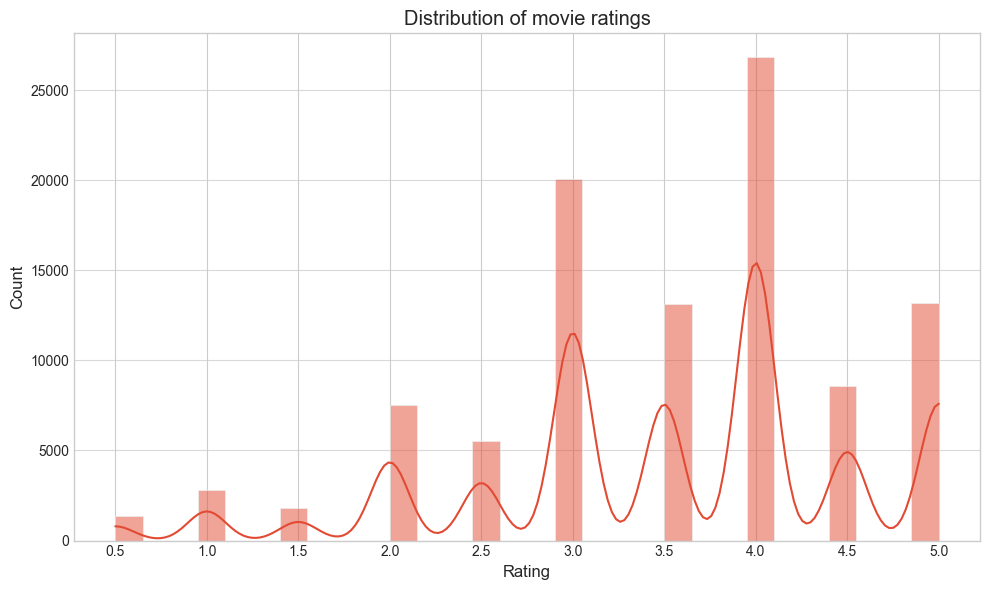

In [118]:
# Ratings distribution
r = ratings["rating"].to_numpy()
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(r, bins=30, kde = True)
plt.title("Distribution of movie ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.grid(axis = "y", alpha = 0.75)
plt.tight_layout()

* We can see bias of ratings across dataset

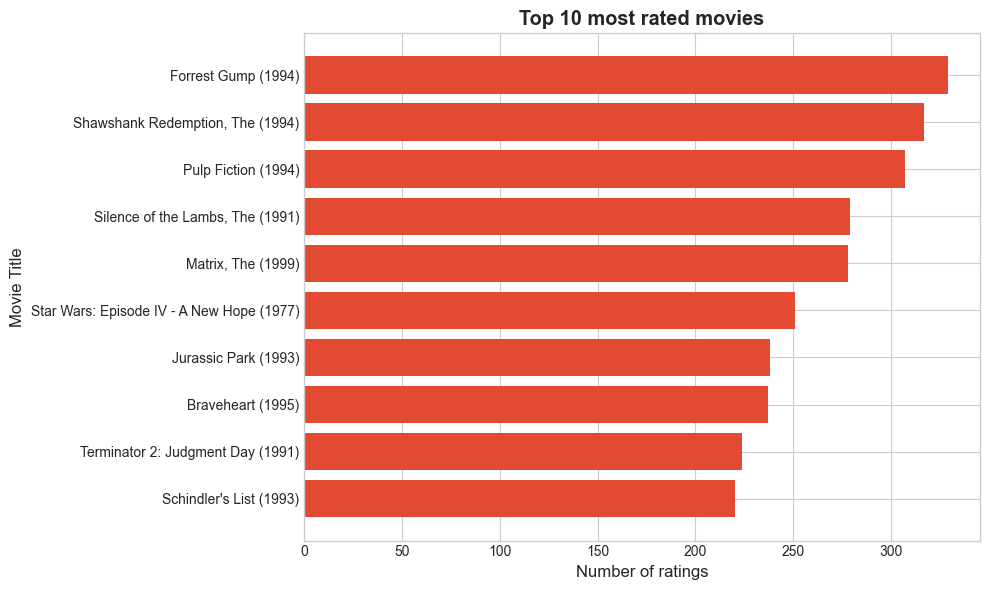

In [119]:
# top 10 most rated movie
movie_counts = (ratings.group_by("movieId").agg(pl.count("rating").alias("rating_count")).sort("rating_count",descending=True).head(10))

top_movies = movie_counts.join(movies, on="movieId", how="left")

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_movies["title"], top_movies["rating_count"])
ax.set_xlabel("Number of ratings")
ax.set_ylabel("Movie Title")
ax.set_title("Top 10 most rated movies", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()


* This can show as what movie can dominate model training because of their high frequency, so we can maybe avoid popularity bias in next steps

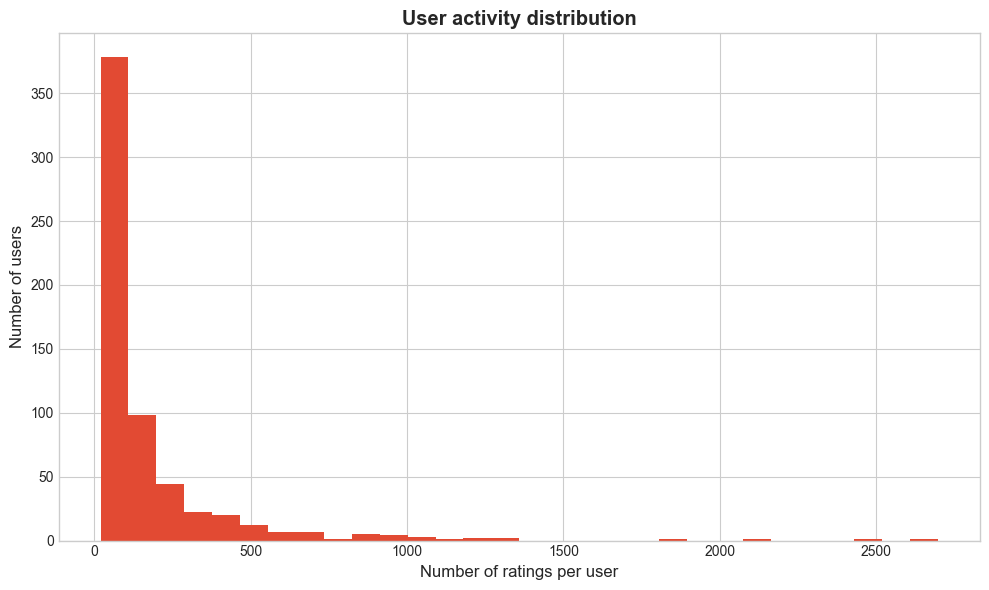

In [120]:
# User activity distribution

user_activity = (ratings.group_by("userId").agg(pl.count("rating").alias("rating_count")).sort("rating_count",descending=True))

plt.style.use("seaborn-v0_8-whitegrid")
fig,ax = plt.subplots(figsize=(10, 6))
ax.hist(user_activity["rating_count"], bins=30)
ax.set_xlabel("Number of ratings per user")
ax.set_ylabel("Number of users")
ax.set_title("User activity distribution", fontweight="bold")
plt.tight_layout()

* Again checking for bias, and distribution of power users against inactive users. We can see that most of the users had rated few movies. This should be assessed in details in the modeling phase since this is bringing bias into model.

***SUMMARY:***

After EDA analysis and validation these are conclusions made based on analysis:

a) Movies dataset:
- There are 5 duplicated titles in the dataset, since rows have different metadata and we don't want duplicate movies in dataset we will merge this rows on title of movie. Duplicated title rows have unique movieId so we need to decide how to handle this when we merge rows. Options we have are: 1) keep movieId with more ratings, if it is a tie return one with more metadata 2) return smaller movieId 3) keep one with more metadata
- Genres column have consistent formatting so we will not need to handle that by ourselves. There are rows with value "(no genres listed)" which we need to exclude through data preparation phase since these rows don't bring value by itself. In addition only one movie from these rows have tags in corresponding rows in tags dataset. (After dropping these rows will need to filter ratings and tags datasets based on unique set of movieIds in movies dataset, since we don't want unmatched movieId from tags and ratings datasets while computing)

Optional:
- We could extract from title year, or something like that in need of presentation.

b) Tags dataset:
- There are no missing values, data types are good and all movieIds that are in tags dataset are present in movies dataset.
- There are similar tags in tag differently written: scifi, sci-fi, science fiction. This should be confronted in data preparation step. Since users were adding tags column tag is messy, so we will use few techniques to make tags cleaner and more accurate. First one is standardization (removing punctuation signs, strip whitespace, lowercase ), handle synonyms and stemming as mentioned above, cleaning tag column from stop/filler words since they will not bring that much of a value and deduplicate identical tags in one row.

c) Ratings dataset:
- There are no missing values, data types are all good except timestamp column which we need to change in preparation step if we want to use timestamp to leave last rating from the user as a validation/test value.
- Range of rating column is good between 0.5 and 5.0
- There are no duplicated rows for same movieId and same userId combined.

After data preparation steps mentioned above we should transform genres and tags into a single textual representation (movie_text) which would be main feature for our TF-IDF model and content similarity matrix.